In [ ]:
"""
MAIN EXECUTION CELL - PARTICLE SIMULATION WITH TIME-DEPENDENT FIELDS

This notebook cell runs the full simulation:
  1. Validates that electromagnetic fields rotate correctly with time
  2. Generates random initial positions for particles
  3. Runs simulations in parallel using multiple CPU cores
  4. Saves results to pickle files for later analysis

Usage: Run this cell after defining all functions in the simulation module.
"""

import numpy as np
import pickle
import time
from tqdm.notebook import tqdm
from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp

# ==========================================
# IMPORT SIMULATION MODULE
# ==========================================
# Import all necessary functions and parameters from the main simulation file
# The module 'pulsar_simulation' contains:
#   - simulate_single_particle: the core function that integrates one particle's trajectory
#   - validate_fields_time_dependence: test function to verify field rotation
#   - R, r_lc, t_max, om: physical constants needed here
from simulation import (
    simulate_single_particle, R, r_lc, t_max, om
)


# ==========================================
# PARALLEL SIMULATION FUNCTION
# ==========================================
def run_simulation_parallel(angles_to_simulate, num_particles, r0_min, r0_max, n_cores=6):
    """
    Run particle simulations in parallel for multiple tilt angles.
    
    For each tilt angle:
      1. Generate random initial positions in a spherical shell (r0_min to r0_max)
      2. Simulate all particles in parallel using ProcessPoolExecutor
      3. Collect results and classify each particle's fate
      4. Save everything to a pickle file
      5. Print summary statistics
    
    Parameters:
        angles_to_simulate: list of tilt angles in DEGREES (e.g., [0, 15, 30, 45,...])
        num_particles: how many particles to simulate per angle
        r0_min: minimum initial radial distance (in units of R)
        r0_max: maximum initial radial distance (in units of R)
        n_cores: number of CPU cores to use (None = use all available)
    """
    # If no core count specified, use all available CPU cores
    if n_cores is None:
        n_cores = mp.cpu_count()
    
    # Print simulation setup info
    print(f"Using {n_cores} cores for parallel processing")
    print(f"Fields: TIME-DEPENDENT (psi = phi - om*t)")
    print(f"Integration: Coordinate time t_span = (0, {t_max:.2f})")
    print(f"Tolerances: rtol=1e-10, atol=1e-12")
    
    # Loop over each tilt angle to simulate
    for ang_deg in angles_to_simulate:
        loop_start = time.time()
        
        # Handle the aligned case (0 degrees)
        # Use a tiny non-zero value to avoid numerical singularities
        # that can occur with perfectly aligned fields
        safe_ang = 0.0000001 if ang_deg == 0 else ang_deg
        X_tilt = float(np.radians(safe_ang))  # Convert to radians
        
        print(f"\n>>> Angle: {ang_deg}° (X_tilt = {X_tilt:.4f} rad)")
        
        # ==========================================
        # GENERATE RANDOM INITIAL POSITIONS
        # ==========================================
        # We want particles uniformly distributed in a SPHERICAL SHELL
        # between r0_min and r0_max. Simple uniform random in r gives
        # too many particles near the center (volume ~ r² dr), so we
        # sample r³ uniformly and take the cube root.
        
        np.random.seed(42)  # Fixed seed for reproducibility
        
        # Uniform distribution in r³ (corrects for spherical volume element)
        u_r = np.random.uniform(0, 1, num_particles)
        r_uniform = (u_r * (r0_max**3 - r0_min**3) + r0_min**3)**(1/3)
        
        # Uniform distribution on the sphere (theta, phi)
        # v_theta is uniform in cos(theta) to get uniform points on a sphere
        v_theta = np.random.uniform(-1, 1, num_particles)
        theta_uniform = np.arccos(v_theta)
        
        # phi is simply uniform in [0, 2π]
        phi_uniform = np.random.uniform(0, 2 * np.pi, num_particles)
        
        # Convert spherical (r, theta, phi) to Cartesian (x, y, z)
        x0_arr = r_uniform * np.sin(theta_uniform) * np.cos(phi_uniform)
        y0_arr = r_uniform * np.sin(theta_uniform) * np.sin(phi_uniform)
        z0_arr = r_uniform * np.cos(theta_uniform)
        
        # ==========================================
        # PREPARE DATA FOR PARALLEL PROCESSING
        # ==========================================
        # Each particle is a tuple: (index, x0, y0, z0, X_tilt)
        # The index is an identifier (useful for debugging)
        particle_data = [(i, x0_arr[i], y0_arr[i], z0_arr[i], X_tilt) 
                        for i in range(num_particles)]
        
        # ==========================================
        # INITIALIZE RESULTS DICTIONARY
        # ==========================================
        # Results are organized by particle fate:
        #   - Crashed: hit the star surface (r = R)
        #   - Ejected: reached escape boundary (r = r_esc)
        #   - Trapped: still orbiting when t_max reached
        # For each fate, we store:
        #   - x, y, z: initial positions
        #   - xf, yf, zf: final positions
        #   - gamas: dictionary with gamma (energy) information
        results = {
            'Crashed': {'x': [], 'y': [], 'z': [], 'xf': [], 'yf': [], 'zf': [], 'gamas': []},
            'Ejected': {'x': [], 'y': [], 'z': [], 'xf': [], 'yf': [], 'zf': [], 'gamas': []},
            'Trapped': {'x': [], 'y': [], 'z': [], 'xf': [], 'yf': [], 'zf': [], 'gamas': []}
        }
        
        # ==========================================
        # RUN SIMULATIONS IN PARALLEL
        # ==========================================
        # ProcessPoolExecutor distributes particles across CPU cores.
        # Each core runs simulate_single_particle independently.
        # tqdm shows a progress bar during execution.
        try:
            with ProcessPoolExecutor(max_workers=n_cores) as executor:
                # executor.map applies simulate_single_particle to each element
                # of particle_data, distributing work across cores
                futures = list(tqdm(
                    executor.map(simulate_single_particle, particle_data),
                    total=num_particles,
                    desc=f"Angle {ang_deg}°"
                ))
                
                # Collect results from all completed simulations
                for result in futures:
                    status, x0, y0, z0, xf, yf, zf, gamma_final = result
                    results[status]['x'].append(x0)
                    results[status]['y'].append(y0)
                    results[status]['z'].append(z0)
                    results[status]['xf'].append(xf)
                    results[status]['yf'].append(yf)
                    results[status]['zf'].append(zf)
                    results[status]['gamas'].append(gamma_final)  # Store the float directly
        
        except Exception as e:
            print(f"Error in parallel processing: {e}")
            raise
        
        # ==========================================
        # SAVE RESULTS TO FILE
        # ==========================================
        # Use pickle to save the entire results dictionary.
        # The filename includes the tilt angle for easy identification.
        # Files can be loaded later with: pickle.load(open(filename, 'rb'))
        filename = f"results_angle_{ang_deg}.pkl"
        with open(filename, 'wb') as f:
            pickle.dump(results, f)
        
        # ==========================================
        # PRINT SUMMARY STATISTICS
        # ==========================================
        elapsed = (time.time() - loop_start) / 60  # Convert seconds to minutes
        
        n_c = len(results['Crashed']['x'])
        n_e = len(results['Ejected']['x'])
        n_t = len(results['Trapped']['x'])
        
        print(f"  Crashed: {n_c} | Ejected: {n_e} | Trapped: {n_t} | Time: {elapsed:.1f} min")
        
        # Print gamma (energy) statistics for each fate category
        # Gamma = Lorentz factor = particle energy in units of mc²
        for status, label in [('Ejected', 'Ej'), ('Crashed', 'Cr'), ('Trapped', 'Tr')]:
            if len(results[status]['gamas']) > 0:
                gammas = results[status]['gamas']  # Already a list of floats!
                if gammas:
                    print(f"  {label}: γ_min={min(gammas):.2f}, γ_max={max(gammas):.2f}, "
                          f"γ_mean={np.mean(gammas):.2f}")

# ==========================================
# EXECUTION (only runs when this script is executed directly,
# not when imported as a module)
# ==========================================
if __name__ == '__main__':
    # ==========================================
    # SIMULATION CONFIGURATION
    # ==========================================
    num_particles = 100       # Number of particles per tilt angle
    r0_min = 1.1 * R           # Minimum initial radius (just above star surface)
    r0_max = 0.9 * r_lc        # Maximum initial radius (just inside light cylinder)
    
    # Tilt angles to simulate (in degrees)
    angles_to_simulate = [0, 15, 30, 45, 60, 75, 90]
    
    # ==========================================
    # PRINT SIMULATION HEADER
    # ==========================================
    print("=" * 60)
    print("TIME-DEPENDENT FIELD SIMULATION")
    print("psi = phi - om*t (corotating pattern)")
    print("=" * 60)
    print(f"Key changes from static version:")
    print(f"  ✓ EM field now explicitly depends on t")
    print(f"  ✓ psi = phi - om*t instead of psi = phi")
    print(f"  ✓ Integration in coordinate (cosmic) time")
    print(f"  ✓ More realistic physics near the light cylinder")
    print("=" * 60)
    print(f"Tilt angles: {angles_to_simulate}°")
    print(f"Particles per angle: {num_particles}")
    print(f"Initial radial range: {r0_min:.2f} to {r0_max:.2f} R")
    print(f"Maximum integration time: {t_max:.2f} (≈ {t_max*om/(2*np.pi):.1f} periods)")
    print(f"Angular frequency: om = {om:.3f}")
    print(f"Light cylinder radius: r_lc = {r_lc:.2f}")
    print("=" * 60)
    
    # ==========================================
    # RUN THE SIMULATION
    # ==========================================
    run_simulation_parallel(angles_to_simulate, num_particles, r0_min, r0_max, n_cores=4)
    
    # ==========================================
    # COMPLETION MESSAGE
    # ==========================================
    print("\n" + "=" * 60)
    print("SIMULATION COMPLETED!")
    print("=" * 60)

TIME-DEPENDENT FIELD SIMULATION
psi = phi - om*t (corotating pattern)
Key changes from static version:
  ✓ EM field now explicitly depends on t
  ✓ psi = phi - om*t instead of psi = phi
  ✓ Integration in coordinate (cosmic) time
  ✓ More realistic physics near the light cylinder
Tilt angles: [0, 15, 30, 45, 60, 75, 90]°
Particles per angle: 100
Initial radial range: 1.10 to 4.31 R
Maximum integration time: 150.32 (≈ 5.0 periods)
Angular frequency: om = 0.209
Light cylinder radius: r_lc = 4.78
Using 4 cores for parallel processing
Fields: TIME-DEPENDENT (psi = phi - om*t)
Integration: Coordinate time t_span = (0, 150.32)
Tolerances: rtol=1e-10, atol=1e-12

>>> Angle: 0° (X_tilt = 0.0000 rad)


Angle 0°:   0%|          | 0/100 [00:00<?, ?it/s]

  Crashed: 0 | Ejected: 99 | Trapped: 1 | Time: 0.5 min
  Ej: γ_min=1.22, γ_max=1.99, γ_mean=1.37
  Tr: γ_min=1.32, γ_max=1.32, γ_mean=1.32

>>> Angle: 15° (X_tilt = 0.2618 rad)


Angle 15°:   0%|          | 0/100 [00:00<?, ?it/s]

Reading data files...
  Angle 0°: Ejected=339, Crashed=4, Trapped=157
  Angle 15°: Ejected=365, Crashed=3, Trapped=132
  Angle 30°: Ejected=391, Crashed=4, Trapped=105
  Angle 45°: Ejected=413, Crashed=6, Trapped=81
  Angle 60°: Ejected=432, Crashed=7, Trapped=61
  Angle 75°: Ejected=418, Crashed=8, Trapped=74
  Angle 90°: Ejected=362, Crashed=17, Trapped=121

Total particles across all angles: 3500
Gamma range: 1.00 to 126.04


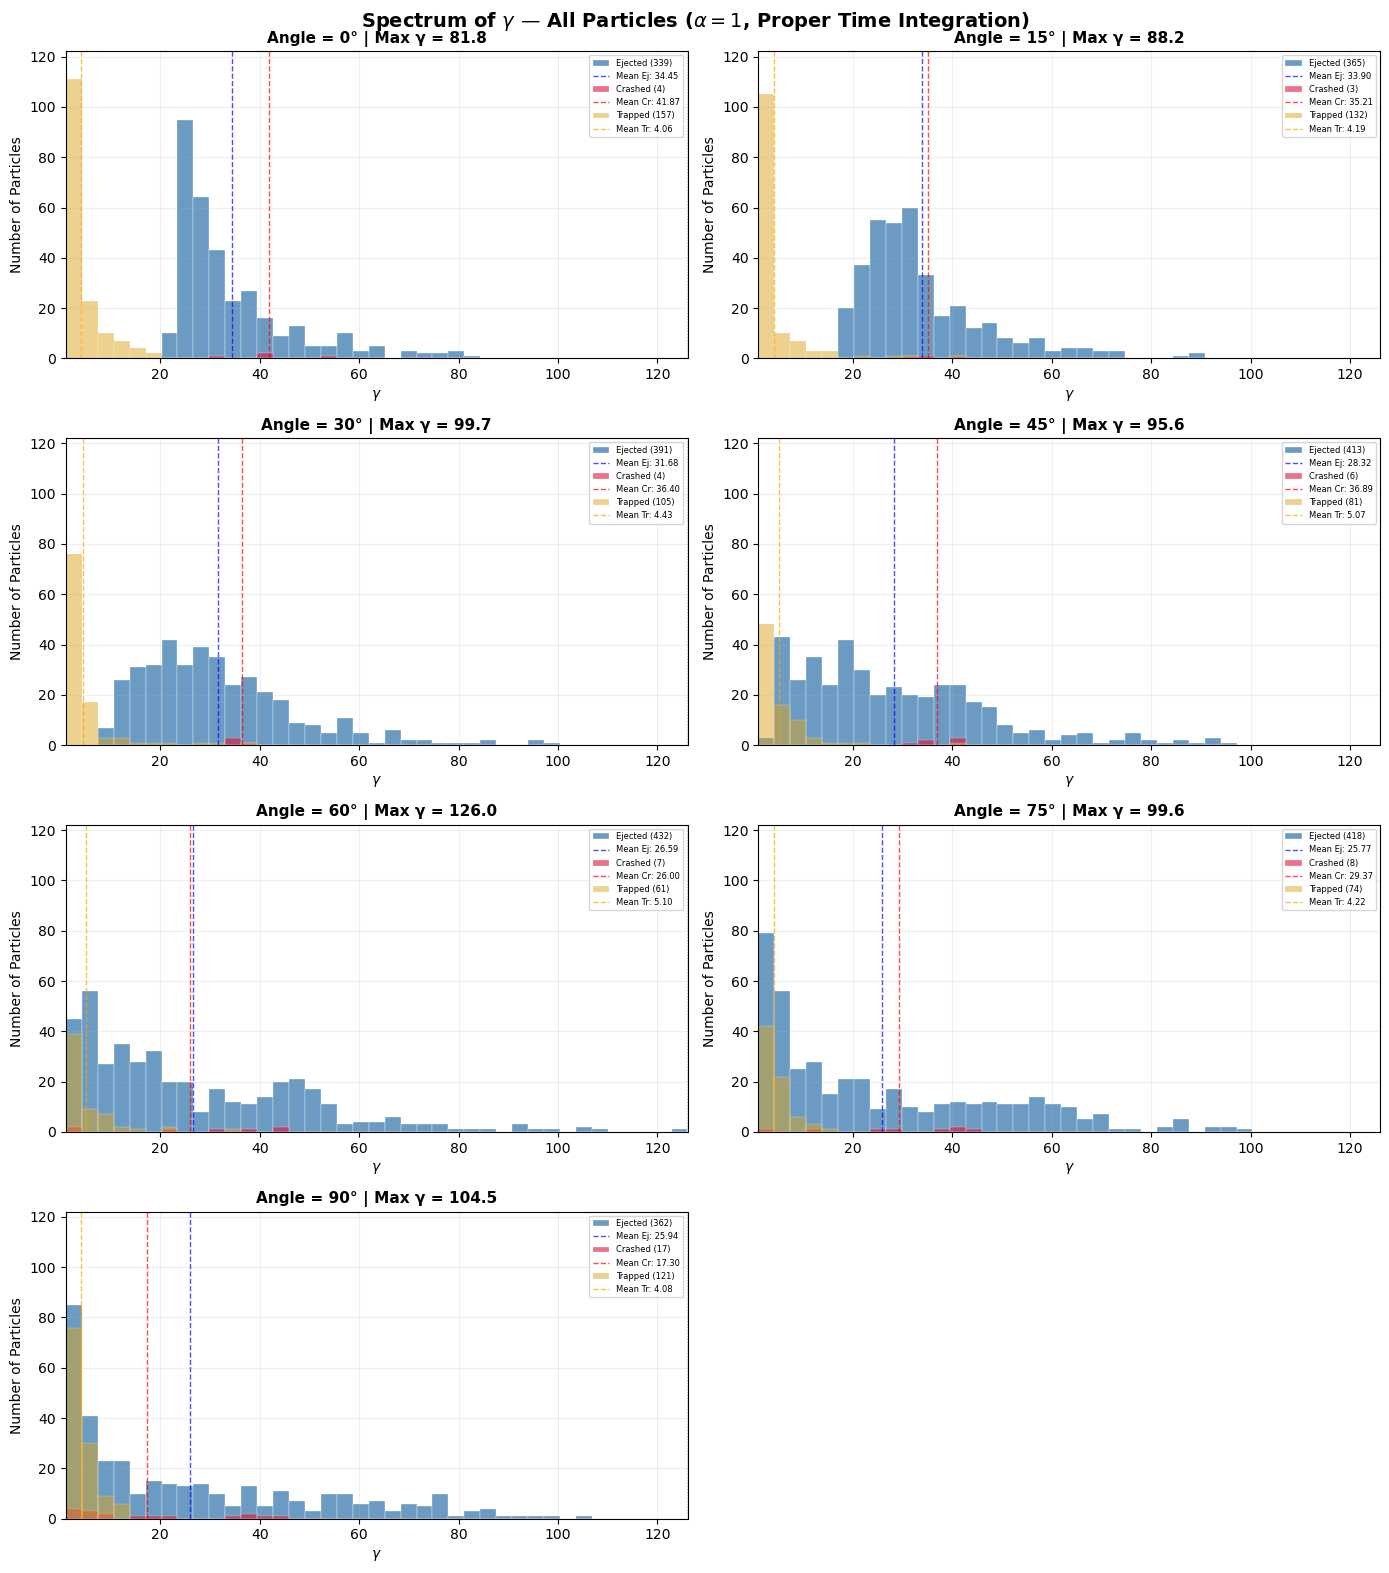

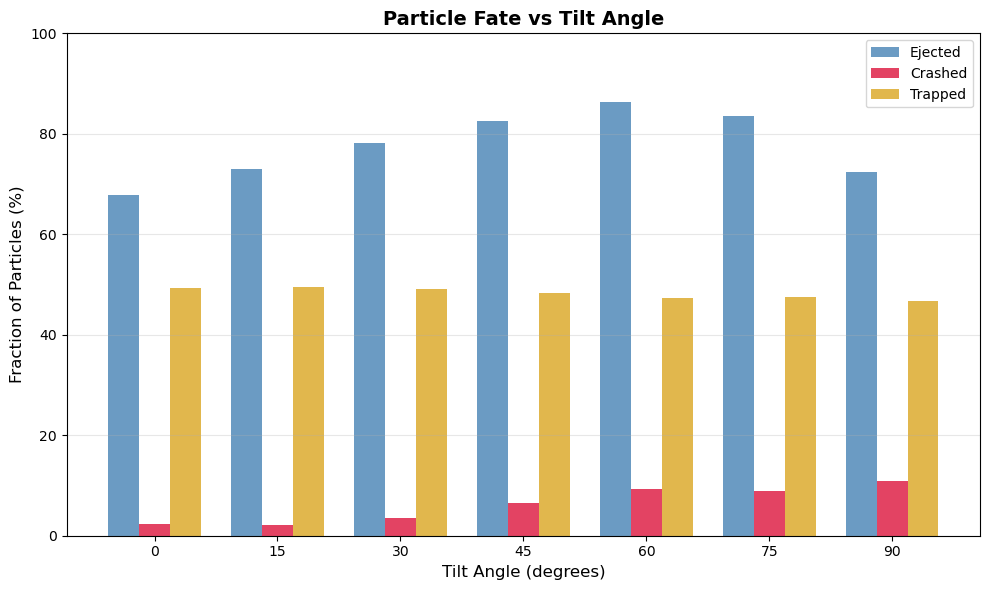


STATISTICS SUMMARY

Angle 0° (Total: 500 particles):
  Ejected (339): mean γ = 34.4539, min = 22.4959, max = 81.7527
  Crashed (4): mean γ = 41.8652, min = 31.6252, max = 53.6056
  Trapped (157): mean γ = 4.0627, min = 1.0003, max = 18.0130

Angle 15° (Total: 500 particles):
  Ejected (365): mean γ = 33.9017, min = 18.6756, max = 88.1789
  Crashed (3): mean γ = 35.2072, min = 31.3630, max = 39.6076
  Trapped (132): mean γ = 4.1947, min = 1.0030, max = 42.5184

Angle 30° (Total: 500 particles):
  Ejected (391): mean γ = 31.6797, min = 9.1930, max = 99.6938
  Crashed (4): mean γ = 36.4012, min = 35.3984, max = 38.1537
  Trapped (105): mean γ = 4.4332, min = 1.0102, max = 39.0411

Angle 45° (Total: 500 particles):
  Ejected (413): mean γ = 28.3241, min = 3.9797, max = 95.6494
  Crashed (6): mean γ = 36.8894, min = 30.4664, max = 42.4125
  Trapped (81): mean γ = 5.0748, min = 1.0431, max = 42.4911

Angle 60° (Total: 500 particles):
  Ejected (432): mean γ = 26.5907, min = 3.0214, max = 12

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# All angles from 0 to 90
angles = [0, 15, 30, 45, 60, 75, 90]

# Create figure with 4 rows and 2 columns (8 subplots, but we only need 7)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

# =============================================
# First pass: collect ALL gamma values and
# histogram heights to determine global scales
# =============================================
all_gammas = []
max_hist_height = 0  # will store the maximum bar height across all plots

# Store histogram data from the first pass
hist_data = {}  # ang -> {'gammas_ej': array, 'gammas_cr': array, 'gammas_tr': array}

print("Reading data files...")
for ang in angles:
    # Updated filename to match your new format
    filename = f"GJ_results_timedep_angle_{ang}.pkl"
    
    try:
        with open(filename, 'rb') as f:
            data = pickle.load(f)
        
        # Extract gamma values for each category
        gammas_ej = np.array([g['final'] for g in data['Ejected']['gamas'] 
                             if g['final'] is not None])
        gammas_cr = np.array([g['final'] for g in data['Crashed']['gamas'] 
                             if g['final'] is not None])
        gammas_tr = np.array([g['final'] for g in data['Trapped']['gamas'] 
                             if g['final'] is not None])
        
        # Collect all gammas for global scale
        all_gammas.extend(gammas_ej.tolist())
        all_gammas.extend(gammas_cr.tolist())
        all_gammas.extend(gammas_tr.tolist())
        
        hist_data[ang] = {
            'gammas_ej': gammas_ej, 
            'gammas_cr': gammas_cr,
            'gammas_tr': gammas_tr
        }
        
        print(f"  Angle {ang}°: Ejected={len(gammas_ej)}, "
              f"Crashed={len(gammas_cr)}, Trapped={len(gammas_tr)}")
    
    except FileNotFoundError:
        print(f"  ⚠️  File not found: {filename}")
        hist_data[ang] = {
            'gammas_ej': np.array([]), 
            'gammas_cr': np.array([]),
            'gammas_tr': np.array([])
        }

# Check if we have any data
if len(all_gammas) == 0:
    print("\n❌ No data found! Make sure the pickle files exist.")
else:
    print(f"\nTotal particles across all angles: {len(all_gammas)}")
    
    # Define global x-axis range and bins
    global_min = np.min(all_gammas)
    global_max = np.max(all_gammas)
    global_bins = np.linspace(global_min, global_max, 40)
    
    print(f"Gamma range: {global_min:.2f} to {global_max:.2f}")
    
    # Compute global maximum histogram height
    for ang in angles:
        for category in ['gammas_ej', 'gammas_cr', 'gammas_tr']:
            gammas = hist_data[ang][category]
            if len(gammas) > 0:
                counts, _ = np.histogram(gammas, bins=global_bins)
                max_hist_height = max(max_hist_height, counts.max())
    
    # Add 10% headroom for visual comfort
    global_ymax = max_hist_height * 1.1
    
    # =============================================
    # Second pass: plot with uniform x AND y scales
    # =============================================
    for idx, ang in enumerate(angles):
        ax = axes[idx]
        
        gammas_ej = hist_data[ang]['gammas_ej']
        gammas_cr = hist_data[ang]['gammas_cr']
        gammas_tr = hist_data[ang]['gammas_tr']
        
        total_particles = len(gammas_ej) + len(gammas_cr) + len(gammas_tr)
        
        if total_particles == 0:
            ax.set_title(f"Angle = {ang}° (no data)", fontsize=11, fontweight='bold')
            ax.set_xlim(global_min, global_max)
            ax.set_ylim(0, global_ymax)
            ax.set_xlabel(r'$\gamma$', fontsize=10)
            ax.set_ylabel('Number of Particles', fontsize=10)
            ax.grid(True, alpha=0.2)
            continue
        
        # Ejected particles
        if len(gammas_ej) > 0:
            ax.hist(gammas_ej, bins=global_bins, color='steelblue', edgecolor='white', 
                    linewidth=0.3, alpha=0.8, label=f'Ejected ({len(gammas_ej)})')
            # Reference lines for ejected
            ax.axvline(gammas_ej.mean(), color='blue', linestyle='--', linewidth=1, alpha=0.7,
                      label=f'Mean Ej: {gammas_ej.mean():.2f}')
        
        # Crashed particles
        if len(gammas_cr) > 0:
            ax.hist(gammas_cr, bins=global_bins, color='crimson', edgecolor='white', 
                    linewidth=0.3, alpha=0.6, label=f'Crashed ({len(gammas_cr)})')
            if len(gammas_cr) > 0:
                ax.axvline(gammas_cr.mean(), color='red', linestyle='--', linewidth=1, alpha=0.7,
                          label=f'Mean Cr: {gammas_cr.mean():.2f}')
        
        # Trapped particles
        if len(gammas_tr) > 0:
            ax.hist(gammas_tr, bins=global_bins, color='goldenrod', edgecolor='white', 
                    linewidth=0.3, alpha=0.5, label=f'Trapped ({len(gammas_tr)})')
            if len(gammas_tr) > 0:
                ax.axvline(gammas_tr.mean(), color='orange', linestyle='--', linewidth=1, alpha=0.7,
                          label=f'Mean Tr: {gammas_tr.mean():.2f}')
        
        # Min and max lines (global)
        ax.axvline(global_min, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
        ax.axvline(global_max, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
        
        # Uniform x AND y limits
        ax.set_xlim(global_min, global_max)
        ax.set_ylim(0, global_ymax)
        
        ax.set_xlabel(r'$\gamma$', fontsize=10)
        ax.set_ylabel('Number of Particles', fontsize=10)
        
        # Title with key statistics
        if len(gammas_ej) > 0:
            title = f"Angle = {ang}° | Max γ = {gammas_ej.max():.1f}"
        elif len(gammas_cr) > 0:
            title = f"Angle = {ang}° | Max γ (Cr) = {gammas_cr.max():.1f}"
        else:
            title = f"Angle = {ang}° | Max γ (Tr) = {gammas_tr.max():.1f}"
        
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.legend(fontsize=6, loc='upper right')
        ax.grid(True, alpha=0.2)
    
    # Hide the 8th subplot (we only have 7 angles)
    axes[7].set_visible(False)
    
    fig.suptitle(r'Spectrum of $\gamma$ — All Particles ($\alpha = 1$, Proper Time Integration)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('espectro_gamma_all_angles.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # =============================================
    # Additional plot: Fraction of particles by category
    # =============================================
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    
    categories = ['Ejected', 'Crashed', 'Trapped']
    colors = ['steelblue', 'crimson', 'goldenrod']
    
    x = np.arange(len(angles))
    width = 0.25
    
    for i, (cat, color) in enumerate(zip(categories, colors)):
        fractions = []
        for ang in angles:
            total = (len(hist_data[ang][f'gammas_{cat[:2].lower()}']) + 
                    len(hist_data[ang]['gammas_cr']) + 
                    len(hist_data[ang]['gammas_tr']))
            if total > 0:
                if cat == 'Ejected':
                    frac = len(hist_data[ang]['gammas_ej']) / total
                elif cat == 'Crashed':
                    frac = len(hist_data[ang]['gammas_cr']) / total
                else:
                    frac = len(hist_data[ang]['gammas_tr']) / total
            else:
                frac = 0
            fractions.append(frac * 100)  # Convert to percentage
        
        ax2.bar(x + i*width, fractions, width, label=cat, color=color, alpha=0.8)
    
    ax2.set_xlabel('Tilt Angle (degrees)', fontsize=12)
    ax2.set_ylabel('Fraction of Particles (%)', fontsize=12)
    ax2.set_title('Particle Fate vs Tilt Angle', fontsize=14, fontweight='bold')
    ax2.set_xticks(x + width)
    ax2.set_xticklabels(angles)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.savefig('particle_fate_fractions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # =============================================
    # Statistics summary
    # =============================================
    print("\n" + "="*60)
    print("STATISTICS SUMMARY")
    print("="*60)
    for ang in angles:
        gammas_ej = hist_data[ang]['gammas_ej']
        gammas_cr = hist_data[ang]['gammas_cr']
        gammas_tr = hist_data[ang]['gammas_tr']
        
        total = len(gammas_ej) + len(gammas_cr) + len(gammas_tr)
        
        print(f"\nAngle {ang}° (Total: {total} particles):")
        
        if len(gammas_ej) > 0:
            print(f"  Ejected ({len(gammas_ej)}): mean γ = {gammas_ej.mean():.4f}, "
                  f"min = {gammas_ej.min():.4f}, max = {gammas_ej.max():.4f}")
        else:
            print(f"  Ejected: 0 particles")
        
        if len(gammas_cr) > 0:
            print(f"  Crashed ({len(gammas_cr)}): mean γ = {gammas_cr.mean():.4f}, "
                  f"min = {gammas_cr.min():.4f}, max = {gammas_cr.max():.4f}")
        else:
            print(f"  Crashed: 0 particles")
        
        if len(gammas_tr) > 0:
            print(f"  Trapped ({len(gammas_tr)}): mean γ = {gammas_tr.mean():.4f}, "
                  f"min = {gammas_tr.min():.4f}, max = {gammas_tr.max():.4f}")
        else:
            print(f"  Trapped: 0 particles")